In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
from sklearn.datasets import make_classification

In [5]:
def make_data(sep):

    X,y = make_classification(
                                n_samples=1000,
                                n_features=2,
                                n_redundant=0,
                                n_clusters_per_class=1,
                                weights=[0.99],
                                class_sep=sep,
                                random_state=1
    )

    X = pd.DataFrame(data=X, columns=['varA', 'varB'])
    y = pd.Series(y)

    return X, y

In [14]:
X, y = make_data(sep=2)

In [10]:
from imblearn.under_sampling import EditedNearestNeighbours

In [8]:
import imblearn.under_sampling

In [9]:
dir(imblearn.under_sampling)

['AllKNN',
 'ClusterCentroids',
 'CondensedNearestNeighbour',
 'EditedNearestNeighbours',
 'InstanceHardnessThreshold',
 'NearMiss',
 'NeighbourhoodCleaningRule',
 'OneSidedSelection',
 'RandomUnderSampler',
 'RepeatedEditedNearestNeighbours',
 'TomekLinks',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_prototype_generation',
 '_prototype_selection',
 'base']

In [11]:
?EditedNearestNeighbours

Init signature:
EditedNearestNeighbours(
    *,
    sampling_strategy='auto',
    n_neighbors=3,
    kind_sel='all',
    n_jobs=None,
)
Docstring:     
Undersample based on the edited nearest neighbour method.

This method cleans the dataset by removing samples close to the
decision boundary. It removes observations from the majority class or
classes when any or most of its closest neighours are from a different class.

Read more in the :ref:`User Guide <edited_nearest_neighbors>`.

Parameters
----------
sampling_strategy : str, list or callable
    Sampling information to sample the data set.

    - When ``str``, specify the class targeted by the resampling. Note the
      the number of samples will not be equal in each. Possible choices
      are:

        ``'majority'``: resample only the majority class;

        ``'not minority'``: resample all classes but the minority class;

        ``'not majority'``: resample all classes but the majority class;

        ``'all'``: resample all 

In [12]:
enn = EditedNearestNeighbours(
                            sampling_strategy='auto',
                            n_neighbors=3,
                            kind_sel='all',
                            n_jobs=-1
)

In [15]:
X_resampled, y_resampled = enn.fit_resample(X, y)

<Axes: xlabel='varA', ylabel='varB'>

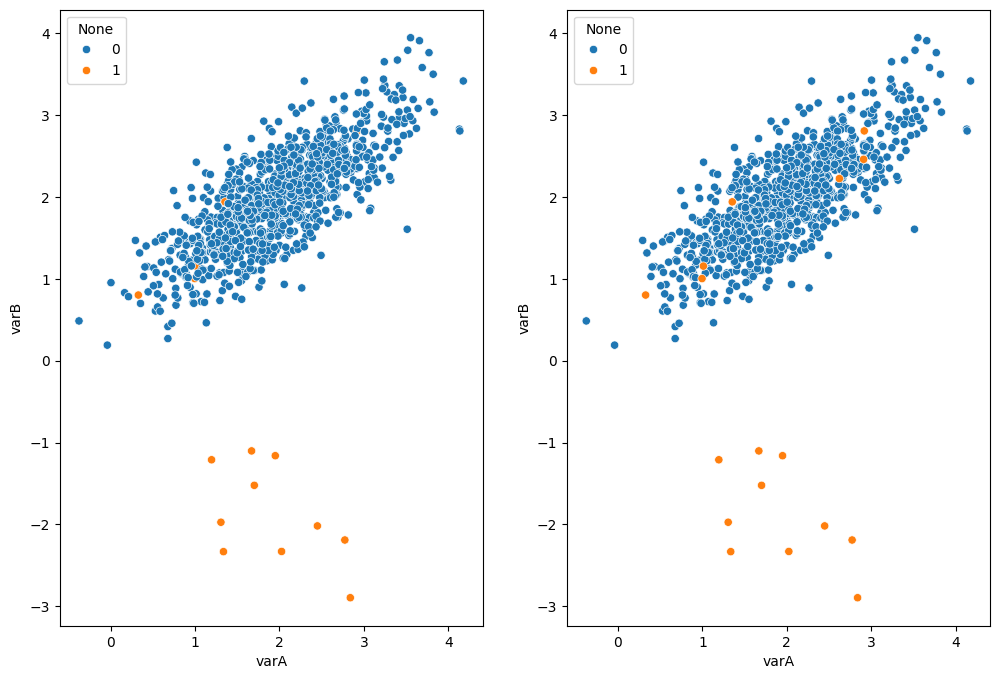

In [16]:
plt.figure(figsize=(12,8))
plt.subplot(121)
sns.scatterplot(data=X, x='varA', y='varB', hue=y)

plt.subplot(122)
sns.scatterplot(data=X_resampled, x='varA', y='varB', hue=y_resampled)

In [17]:
X, y = make_data(sep=0.1)

enn = EditedNearestNeighbours(
    sampling_strategy='auto',
    n_neighbors=3,
    kind_sel='all',
    n_jobs=-1
)

In [18]:
X_resampled, y_resampled = enn.fit_resample(X,y)

<Axes: xlabel='varA', ylabel='varB'>

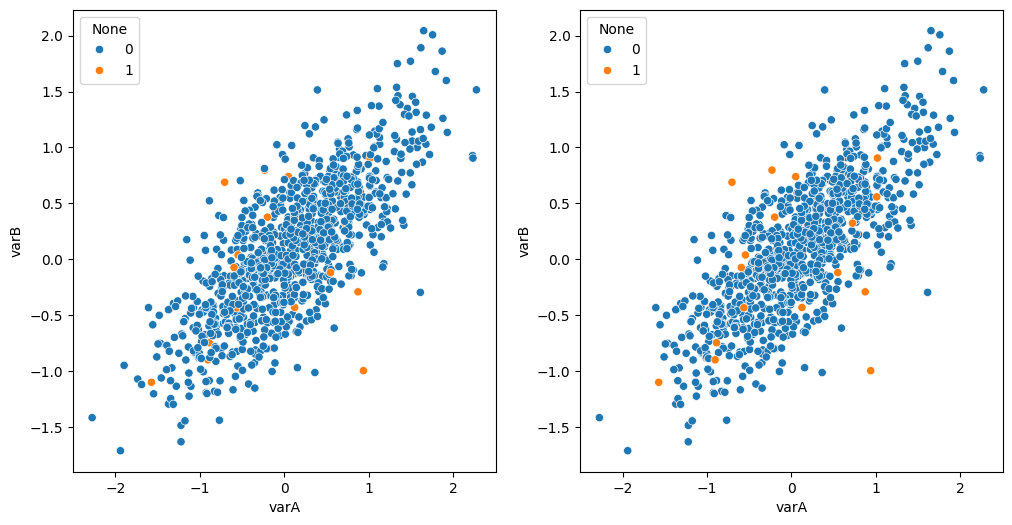

In [20]:
plt.figure(figsize=(12,6))
plt.subplot(121)
sns.scatterplot(data=X, x='varA', y='varB', hue=y)

plt.subplot(122)
sns.scatterplot(data=X_resampled, x='varA', y='varB', hue=y_resampled)

In [22]:
df = pd.read_csv('../kdd2004.csv')
df.head()

,0,1,2,3,4,5,6,7,8,9,...,65,66,67,68,69,70,71,72,73,target
0,52.0,32.69,0.30,2.5,20.0,1256.8,-0.89,0.33,11.0,-55.0,...,1595.1,-1.64,2.83,-2.0,-50.0,445.2,-0.35,0.26,0.76,-1
1,58.0,33.33,0.00,16.5,9.5,608.1,0.50,0.07,20.5,-52.5,...,762.9,0.29,0.82,-3.0,-35.0,140.3,1.16,0.39,0.73,-1
2,77.0,27.27,-0.91,6.0,58.5,1623.6,-1.40,0.02,-6.5,-48.0,...,1491.8,0.32,-1.29,0.0,-34.0,658.2,-0.76,0.26,0.24,-1
3,41.0,27.91,-0.35,3.0,46.0,1921.6,-1.36,-0.47,-32.0,-51.5,...,2047.7,-0.98,1.53,0.0,-49.0,554.2,-0.83,0.39,0.73,-1
4,50.0,28.00,-1.32,-9.0,12.0,464.8,0.88,0.19,8.0,-51.5,...,479.5,0.68,-0.59,2.0,-36.0,-6.9,2.02,0.14,-0.23,-1


In [23]:
df.target.value_counts()

target
-1    144455
 1      1296
Name: count, dtype: int64

In [24]:
from sklearn.model_selection import train_test_split, GridSearchCV

In [25]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('target', axis=1), df.target, test_size=0.3, random_state=0)

In [26]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
from sklearn.metrics import roc_auc_score

In [33]:
X_train.head()

,0,1,2,3,4,5,6,7,8,9,...,64,65,66,67,68,69,70,71,72,73
120222,69.91,27.38,0.59,-9.5,-8.5,1065.4,-1.44,0.87,-4.0,-62.0,...,47.0,504.2,-1.20,1.97,-6.0,-24.0,21.0,0.81,0.63,0.78
38087,42.40,30.19,0.12,14.0,9.0,1417.1,-1.67,0.30,9.5,-51.5,...,-8.0,1145.1,-1.62,2.55,1.0,-45.0,320.7,0.11,0.22,0.36
58290,41.44,24.52,0.01,52.0,-8.0,3121.7,-0.10,1.03,-2.0,-122.5,...,-87.0,2620.7,0.84,0.46,3.0,-156.0,605.8,1.95,0.09,0.47
79865,41.63,27.45,0.02,-10.0,6.0,2321.1,-0.52,-0.02,-0.5,-80.0,...,34.0,2517.9,-0.19,0.17,-2.0,-46.0,205.7,1.61,0.01,-0.23
45816,51.02,30.67,-0.93,-34.5,33.0,1018.3,1.14,0.06,9.5,-64.5,...,1.0,1363.9,0.35,-2.00,-13.0,-43.0,549.0,-0.60,0.23,0.18


In [34]:
def runRandomForest(X_train, X_test, y_train, y_test):

    rf = RandomForestClassifier(n_estimators=200, 
                                criterion='entropy',
                                max_depth=4,
                                random_state=0)
    rf.fit(X_train, y_train)
    y_prob = rf.predict_proba(X_train)[:,1]
    print("Train RF roc-auc score: {}".format(roc_auc_score(y_train, y_prob)))

    y_prob = rf.predict_proba(X_test)[:,1]
    print('Test RF roc-auc score: {}'.format(roc_auc_score(y_test, y_prob)))

In [35]:
runRandomForest(X_train, X_test, y_train, y_test)

Train RF roc-auc score: 0.9864891279911616
Test RF roc-auc score: 0.9863127995688801


In [37]:
enn = EditedNearestNeighbours(
    sampling_strategy='auto',
    n_neighbors=3,
    kind_sel='all',
    n_jobs=-1
)

In [38]:
X_resampled, y_resampled = enn.fit_resample(X_train, y_train)

In [39]:
runRandomForest(X_resampled, X_test, y_resampled, y_test)

Train RF roc-auc score: 0.9866540642709432
Test RF roc-auc score: 0.9869454582657571
